In [1]:
import pandas as pd
import numpy as np
import pycountry
import os, warnings, time, json, re
warnings.filterwarnings('ignore')

DATA_DIR = os.path.join(os.getcwd(), 'dataset')
print(f'Data directory: {DATA_DIR}')
print(f'Exists: {os.path.isdir(DATA_DIR)}')

Data directory: c:\Users\LUCKY SURYA\Documents\kuliah\semester 4\data warehouse\UAS\dataset
Exists: True


---
## 1. ETL — EXTRACT
Membaca seluruh dataset CSV mentah dari folder dataset.

In [2]:
df_both       = pd.read_csv(os.path.join(DATA_DIR, 'penyebab utama kematian.csv'))
df_female     = pd.read_csv(os.path.join(DATA_DIR, 'female.csv'))
df_male       = pd.read_csv(os.path.join(DATA_DIR, 'male.csv'))
df_life_exp   = pd.read_csv(os.path.join(DATA_DIR, 'RELAY_WHS (3).csv'))
df_healthy_life = pd.read_csv(os.path.join(DATA_DIR, 'RELAY_WHS (5).csv'))

print('Dataset shape:')
print(f'  Mortality (both sexes) : {df_both.shape}')
print(f'  Mortality (female)     : {df_female.shape}')
print(f'  Mortality (male)       : {df_male.shape}')
print(f'  Life Expectancy        : {df_life_exp.shape}')
print(f'  Healthy Life Exp       : {df_healthy_life.shape}')

print('\nContoh data mortality:')
df_both.head(3)

Dataset shape:
  Mortality (both sexes) : (24522, 5)
  Mortality (female)     : (24522, 5)
  Mortality (male)       : (24522, 5)
  Life Expectancy        : (12936, 13)
  Healthy Life Exp       : (12936, 13)

Contoh data mortality:


,DIM_COUNTRY_CODE,DIM_YEAR_CODE,DIM_GHECAUSE_TITLE,DIM_SEX_CODE,VAL_DTHS_RATE100K_NUMERIC
0,AFG,2021,Syphilis,BTSX,1.46
1,AFG,2021,Genital herpes,BTSX,0.00
2,AFG,2021,Diphtheria,BTSX,0.11


In [3]:
print('Contoh data life expectancy:')
df_life_exp.head(3)

Contoh data life expectancy:


,IND_ID,IND_CODE,IND_UUID,IND_PER_CODE,DIM_TIME,DIM_TIME_TYPE,DIM_GEO_CODE_M49,DIM_GEO_CODE_TYPE,DIM_PUBLISH_STATE_CODE,IND_NAME,GEO_NAME_SHORT,DIM_SEX,AMOUNT_N
0,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2000,YEAR,702,COUNTRY,PUBLISHED,Life expectancy (at birth),Singapore,FEMALE,80.774170
1,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2000,YEAR,703,COUNTRY,PUBLISHED,Life expectancy (at birth),Slovakia,FEMALE,77.405510
2,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2006,YEAR,462,COUNTRY,PUBLISHED,Life expectancy (at birth),Maldives,FEMALE,75.095393


In [4]:
print('Contoh data healthy life expectancy:')
df_healthy_life.head(3)

Contoh data healthy life expectancy:


,IND_ID,IND_CODE,IND_UUID,IND_PER_CODE,DIM_TIME,DIM_TIME_TYPE,DIM_GEO_CODE_M49,DIM_GEO_CODE_TYPE,DIM_PUBLISH_STATE_CODE,IND_NAME,GEO_NAME_SHORT,DIM_SEX,AMOUNT_N
0,C64284DWHOSIS_000002,WHOSIS_000002,C64284D,WHOSIS_000002,2002,YEAR,862,COUNTRY,PUBLISHED,Healthy life expectancy (at birth),Venezuela (Bolivarian Republic of),FEMALE,66.668565
1,C64284DWHOSIS_000002,WHOSIS_000002,C64284D,WHOSIS_000002,2002,YEAR,882,COUNTRY,PUBLISHED,Healthy life expectancy (at birth),Samoa,FEMALE,62.499757
2,C64284DWHOSIS_000002,WHOSIS_000002,C64284D,WHOSIS_000002,2002,YEAR,887,COUNTRY,PUBLISHED,Healthy life expectancy (at birth),Yemen,FEMALE,54.872124


---
## 2. ETL — TRANSFORM
### 2.1 Dimensional Modeling (Star Schema)

**Skema:**
- `dim_country` (country_id, country_code, country_name, m49_code)
- `dim_year` (year_id, year)
- `dim_cause` (cause_id, cause_name, cause_category)
- `dim_sex` (sex_id, sex_code, sex_name)
- `fact_mortality` (country_id, year_id, cause_id, sex_id, death_rate)
- `fact_life_expectancy` (country_id, year_id, sex_id, life_expectancy, healthy_life_expectancy)

### 2.2 Dimension: Country

In [5]:
iso3_codes = sorted(set(df_both['DIM_COUNTRY_CODE'].unique()))
print(f'Total negara (ISO3): {len(iso3_codes)}')

country_map = {}
for code in iso3_codes:
    try:
        c = pycountry.countries.get(alpha_3=code)
        if c:
            country_map[code] = {'country_name': c.name, 'm49_code': c.numeric}
        else:
            country_map[code] = {'country_name': code, 'm49_code': None}
    except:
        country_map[code] = {'country_name': code, 'm49_code': None}

dim_country = pd.DataFrame([
    {'country_code': k, 'country_name': v['country_name'], 'm49_code': v['m49_code']}
    for k, v in country_map.items()
])
dim_country['country_id'] = range(1, len(dim_country) + 1)

unmapped = dim_country[dim_country['m49_code'].isna()]
if len(unmapped) > 0:
    print(f'Negara tanpa M49: {unmapped["country_code"].tolist()}')
else:
    print('Semua negara berhasil di-mapping!')

print(f'dim_country: {dim_country.shape}')
dim_country.head(10)

Total negara (ISO3): 183
Semua negara berhasil di-mapping!
dim_country: (183, 4)


,country_code,country_name,m49_code,country_id
0,AFG,Afghanistan,004,1
1,AGO,Angola,024,2
2,ALB,Albania,008,3
3,ARE,United Arab Emirates,784,4
4,ARG,Argentina,032,5
5,ARM,Armenia,051,6
6,ATG,Antigua and Barbuda,028,7
7,AUS,Australia,036,8
8,AUT,Austria,040,9
9,AZE,Azerbaijan,031,10


### 2.3 Dimension: Cause (dengan Kategori)

In [6]:
cause_categories = {
    'Communicable': [
        'Tuberculosis', 'HIV/AIDS', 'Diarrhoeal diseases', 'Lower respiratory infections',
        'Meningitis', 'Malaria', 'COVID-19', 'Measles', 'Tetanus', 'Diphtheria',
        'Whooping cough', 'Acute hepatitis B', 'Acute hepatitis C', 'Acute hepatitis E',
        'Acute hepatitis A', 'Syphilis', 'Genital herpes', 'Dengue', 'Rabies',
        'African trypanosomiasis', 'Chagas disease', 'Schistosomiasis', 'Leishmaniasis',
        'Echinococcosis', 'Food-bourne trematodes', 'Leprosy', 'Trachoma',
        'Trichomoniasis', 'Chlamydia', 'Gonorrhoea', 'Onchocerciasis',
        'Lymphatic filariasis', 'Hookworm disease', 'Ascariasis', 'Trichuriasis',
        'Cysticercosis', 'Yellow fever', 'Encephalitis', 'Upper respiratory infections',
        'Otitis media', 'Maternal conditions', 'Neonatal sepsis and infections',
        'Preterm birth complications', 'Birth asphyxia and birth trauma',
        'Protein-energy malnutrition', 'Vitamin A deficiency', 'Iodine deficiency',
        'Iron-deficiency anaemia'
    ],
    'Non-communicable': [
        'Ischaemic heart disease', 'Stroke', 'Chronic obstructive pulmonary disease',
        'Trachea, bronchus, lung cancers', 'Diabetes mellitus', 'Kidney diseases',
        'Hypertensive heart disease', 'Alzheimer disease and other dementias',
        'Colon and rectum cancers', 'Stomach cancer', 'Breast cancer',
        'Liver cancer', 'Pancreas cancer', 'Prostate cancer', 'Leukaemia',
        'Oesophagus cancer', 'Cervix uteri cancer', 'Ovary cancer',
        'Bladder cancer', 'Lymphomas, multiple myeloma', 'Brain and nervous system cancers',
        'Kidney cancer', 'Corpus uteri cancer', 'Gallbladder and biliary tract cancer',
        'Melanoma and other skin cancers', 'Thyroid cancer', 'Larynx cancer',
        'Mouth and oropharynx cancers', 'Cardiomyopathy, myocarditis, endocarditis',
        'Asthma', 'Cirrhosis of the liver', 'Peptic ulcer disease',
        'Gallbladder and biliary diseases', 'Pancreatitis', 'Appendicitis',
        'Paralytic ileus and intestinal obstruction', 'Inflammatory bowel disease',
        'Gastritis and duodenitis', 'Skin diseases', 'Rheumatic heart disease',
        'Parkinson disease', 'Epilepsy', 'Multiple sclerosis',
        'Alcohol use disorders', 'Drug use disorders', 'Depressive disorders',
        'Anxiety disorders', 'Schizophrenia', 'Bipolar disorder',
        'Eating disorders', 'Autism and Asperger syndrome',
        'Childhood behavioural disorders', 'Idiopathic intellectual disability',
        'Non-migraine headache', 'Migraine', 'Cataracts', 'Glaucoma',
        'Macular degeneration', 'Uncorrected refractive errors', 'Other hearing loss',
        'Other vision loss', 'Oral conditions', 'Back and neck pain',
        'Osteoarthritis', 'Rheumatoid arthritis', 'Gout', 'Benign prostatic hyperplasia',
        'Urolithiasis', 'Infertility', 'Gynecological diseases',
        'Congenital anomalies', 'Sudden infant death syndrome',
        'Sickle cell disorders and trait', 'Thalassaemias', 'Mesothelioma',
        'Testicular cancer'
    ],
    'Injury': [
        'Road injury', 'Falls', 'Drowning', 'Poisonings', 'Fire, heat and hot substances',
        'Exposure to mechanical forces', 'Self-harm', 'Interpersonal violence',
        'Collective violence and legal intervention', 'Natural disasters'
    ]
}

cause_to_cat = {c: cat for cat, causes in cause_categories.items() for c in causes}

causes = sorted(df_both['DIM_GHECAUSE_TITLE'].unique())
dim_cause = pd.DataFrame({
    'cause_id': range(1, len(causes) + 1),
    'cause_name': causes,
    'cause_category': [cause_to_cat.get(c, 'Other') for c in causes]
})

print(f'dim_cause: {dim_cause.shape}')
print('Distribusi kategori:')
print(dim_cause['cause_category'].value_counts())
dim_cause.head(5)

dim_cause: (134, 3)
Distribusi kategori:
cause_category
Non-communicable    76
Communicable        48
Injury              10
Name: count, dtype: int64


,cause_id,cause_name,cause_category
0,1,Acute hepatitis A,Communicable
1,2,Acute hepatitis B,Communicable
2,3,Acute hepatitis C,Communicable
3,4,Acute hepatitis E,Communicable
4,5,African trypanosomiasis,Communicable


### 2.4 Dimension: Sex & Year

In [7]:
# Dimension Sex
dim_sex = pd.DataFrame({
    'sex_id': [1, 2, 3, 4],
    'sex_code': ['BTSX', 'FMLE', 'MLE', 'TOTAL'],
    'sex_name': ['Both sexes', 'Female', 'Male', 'Total']
})
print('dim_sex:')
print(dim_sex.to_string(index=False))

# Dimension Year (2000-2021)
mortality_years = df_both['DIM_YEAR_CODE'].unique()
life_years = df_life_exp['DIM_TIME'].unique()
all_years = sorted(set(int(y) for y in list(mortality_years) + list(life_years)))

dim_year = pd.DataFrame({'year': all_years, 'year_id': range(1, len(all_years) + 1)})
print(f'\ndim_year: {dim_year.shape} — rentang {all_years[0]} s.d. {all_years[-1]}')
dim_year.head(10)

dim_sex:
 sex_id sex_code   sex_name
      1     BTSX Both sexes
      2     FMLE     Female
      3      MLE       Male
      4    TOTAL      Total

dim_year: (22, 2) — rentang 2000 s.d. 2021


,year,year_id
0,2000,1
1,2001,2
2,2002,3
3,2003,4
4,2004,5
5,2005,6
6,2006,7
7,2007,8
8,2008,9
9,2009,10


### 2.5 Fact Table: Mortality

> **Periodic Extraction Simulation:** Data asli hanya 2021. Untuk memenuhi syarat span 1-2 tahun,
> kita simulasikan batch periodik: Batch 1 (2021) = data asli + Batch 2 (2020) = replika dengan noise ±10%.

In [8]:
np.random.seed(42)

df_both_2020    = df_both.copy()
df_female_2020  = df_female.copy()
df_male_2020    = df_male.copy()

for df_sim in [df_both_2020, df_female_2020, df_male_2020]:
    df_sim['DIM_YEAR_CODE'] = 2020
    noise = np.random.uniform(0.90, 1.10, size=len(df_sim))
    df_sim['VAL_DTHS_RATE100K_NUMERIC'] = (
        df_sim['VAL_DTHS_RATE100K_NUMERIC'] * noise
    ).round(2)

print('=== Simulasi Periodic Extraction ===')
print(f'Batch 1 (2021): {len(df_both):,} records (data asli)')
print(f'Batch 2 (2020): {len(df_both_2020):,} records (simulasi + noise)')

df_fact_mortality = pd.concat(
    [df_both, df_female, df_male,
     df_both_2020, df_female_2020, df_male_2020],
    ignore_index=True
)
print(f'Combined mortality (2020+2021): {df_fact_mortality.shape}')
print(f'  - 2021 records: {len(df_fact_mortality[df_fact_mortality["DIM_YEAR_CODE"]==2021])}')
print(f'  - 2020 records: {len(df_fact_mortality[df_fact_mortality["DIM_YEAR_CODE"]==2020])}')

=== Simulasi Periodic Extraction ===
Batch 1 (2021): 24,522 records (data asli)
Batch 2 (2020): 24,522 records (simulasi + noise)
Combined mortality (2020+2021): (147132, 5)
  - 2021 records: 73566
  - 2020 records: 73566


In [9]:
country_id_map = dict(zip(dim_country['country_code'], dim_country['country_id']))
cause_id_map   = dict(zip(dim_cause['cause_name'], dim_cause['cause_id']))
sex_id_map     = dict(zip(dim_sex['sex_code'], dim_sex['sex_id']))
year_id_map    = dict(zip(dim_year['year'], dim_year['year_id']))

df_fact_mortality['country_id'] = df_fact_mortality['DIM_COUNTRY_CODE'].map(country_id_map)
df_fact_mortality['cause_id']   = df_fact_mortality['DIM_GHECAUSE_TITLE'].map(cause_id_map)
df_fact_mortality['sex_id']     = df_fact_mortality['DIM_SEX_CODE'].map(sex_id_map)
df_fact_mortality['year_id']    = df_fact_mortality['DIM_YEAR_CODE'].map(year_id_map)
df_fact_mortality['death_rate'] = pd.to_numeric(
    df_fact_mortality['VAL_DTHS_RATE100K_NUMERIC'], errors='coerce'
)

fact_mortality = df_fact_mortality[
    ['country_id', 'year_id', 'cause_id', 'sex_id', 'death_rate']
].copy()

before = len(fact_mortality)
fact_mortality = fact_mortality.dropna()
print(f'fact_mortality: {len(fact_mortality):,} rows (dropped {before - len(fact_mortality)} unmapped)')

fact_mortality[['country_id', 'year_id', 'cause_id', 'sex_id']] = (
    fact_mortality[['country_id', 'year_id', 'cause_id', 'sex_id']].astype(int)
)

print(f'\nStatistik death_rate:')
print(fact_mortality['death_rate'].describe())
fact_mortality.head()

fact_mortality: 147,132 rows (dropped 0 unmapped)

Statistik death_rate:
count    147132.000000
mean          5.821990
std          23.077915
min           0.000000
25%           0.000000
50%           0.190000
75%           2.650000
max         720.900000
Name: death_rate, dtype: float64


,country_id,year_id,cause_id,sex_id,death_rate
0,1,22,119,1,1.46
1,1,22,52,1,0.00
2,1,22,38,1,0.11
3,1,22,5,1,0.00
4,1,22,34,1,0.00


### 2.6 Fact Table: Life Expectancy

In [10]:
df_le_country  = df_life_exp[df_life_exp['DIM_GEO_CODE_TYPE'] == 'COUNTRY'].copy()
df_hle_country = df_healthy_life[df_healthy_life['DIM_GEO_CODE_TYPE'] == 'COUNTRY'].copy()

print(f'Life exp (country only): {df_le_country.shape}')
print(f'Healthy life exp (country only): {df_hle_country.shape}')

df_le = df_le_country[['DIM_TIME', 'DIM_GEO_CODE_M49', 'DIM_SEX', 'AMOUNT_N']].copy()
df_le.columns = ['year', 'm49_code', 'sex', 'life_expectancy']

df_hle = df_hle_country[['DIM_TIME', 'DIM_GEO_CODE_M49', 'DIM_SEX', 'AMOUNT_N']].copy()
df_hle.columns = ['year', 'm49_code', 'sex', 'healthy_life_expectancy']

fact_life = pd.merge(df_le, df_hle, on=['year', 'm49_code', 'sex'], how='outer')
print(f'fact_life (merged): {fact_life.shape}')

m49_to_country_code = {}
for _, row in dim_country.iterrows():
    if pd.notna(row['m49_code']):
        m49_to_country_code[int(row['m49_code'])] = row['country_code']

fact_life['m49_code'] = fact_life['m49_code'].astype(int)
fact_life['country_code'] = fact_life['m49_code'].map(m49_to_country_code)
fact_life['country_id'] = fact_life['country_code'].map(country_id_map)
fact_life['year_id'] = fact_life['year'].map(year_id_map)
fact_life['sex_id'] = fact_life['sex'].map({'FEMALE': 2, 'MALE': 3, 'TOTAL': 4})

before = len(fact_life)
fact_life = fact_life.dropna(subset=['country_id', 'year_id', 'sex_id'])
print(f'fact_life after mapping: {len(fact_life):,} rows (dropped {before - len(fact_life)})')

fact_life[['country_id', 'year_id', 'sex_id']] = (
    fact_life[['country_id', 'year_id', 'sex_id']].astype(int)
)

fact_life = fact_life[['country_id', 'year_id', 'sex_id', 'life_expectancy', 'healthy_life_expectancy']]
print(f'\nStatistik harapan hidup:')
print(fact_life[['life_expectancy', 'healthy_life_expectancy']].describe())
fact_life.head()

Life exp (country only): (12078, 13)
Healthy life exp (country only): (12078, 13)
fact_life (merged): (12078, 5)
fact_life after mapping: 12,078 rows (dropped 0)

Statistik harapan hidup:
       life_expectancy  healthy_life_expectancy
count     12078.000000             12078.000000
mean         70.117161                60.991277
std           8.917744                 7.455924
min          36.599153                31.884329
25%          64.058075                56.071372
50%          71.759731                62.760557
75%          77.061597                66.656963
max          87.371027                75.113417


,country_id,year_id,sex_id,life_expectancy,healthy_life_expectancy
0,1,1,2,54.429579,46.154851
1,1,1,3,53.249991,45.943669
2,1,1,4,53.823326,46.027950
3,3,1,2,77.062201,66.808087
4,3,1,3,70.683987,62.425162


---
## 3. ETL — LOAD (Supabase PostgreSQL)

**Eksekusi DDL + Insert Data + Ukuran Database**

In [11]:
from sqlalchemy import create_engine, text
from sqlalchemy.exc import SQLAlchemyError
import getpass

# ========== KONFIGURASI SUPABASE ==========
# Isi sesuai project Supabase Anda
DB_CONFIG = {
    'host': 'db.acynhugxakjqkpwqggmf.supabase.co',
    'port': 5432,
    'dbname': 'postgres',
    'user': 'postgres',
    'password': 'luckysuryar123'  # akan diisi via getpass
}

if DB_CONFIG['password'] is None:
    DB_CONFIG['password'] = getpass.getpass('Masukkan password Supabase PostgreSQL: ')

DB_URL = f"postgresql://{DB_CONFIG['user']}:{DB_CONFIG['password']}@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['dbname']}"
print(f'Connecting to: {DB_CONFIG["host"]}:{DB_CONFIG["port"]}/{DB_CONFIG["dbname"]}')

try:
    engine = create_engine(DB_URL, pool_pre_ping=True)
    with engine.connect() as conn:
        result = conn.execute(text('SELECT version()'))
        print('\nConnected! PostgreSQL version:')
        for row in result:
            print(f'  {row[0]}')
except Exception as e:
    print(f'ERROR: Gagal konek ke Supabase — {e}')
    print('Perbaiki kredensial DB_CONFIG di atas lalu jalankan ulang sel ini.')

Connecting to: db.acynhugxakjqkpwqggmf.supabase.co:5432/postgres

Connected! PostgreSQL version:
  PostgreSQL 17.6 on aarch64-unknown-linux-gnu, compiled by gcc (GCC) 15.2.0, 64-bit


### 3.1 Eksekusi DDL
Membuat tabel dimensi, fakt partisi, indeks, dan materialized views.

In [12]:
DDL = '''
-- =========================================================
-- DDL — Data Warehouse Kematian Global & Harapan Hidup
-- PostgreSQL + Extensions + Partition + Indexes + MV
-- =========================================================

-- 1. Extensions
CREATE EXTENSION IF NOT EXISTS pg_stat_statements;
CREATE EXTENSION IF NOT EXISTS pgcrypto;

-- 2. dim_country
CREATE TABLE IF NOT EXISTS dim_country (
    country_id    INTEGER PRIMARY KEY,
    country_code  VARCHAR(3) NOT NULL UNIQUE,
    country_name  VARCHAR(100) NOT NULL,
    m49_code      INTEGER
);

-- 3. dim_year
CREATE TABLE IF NOT EXISTS dim_year (
    year_id  INTEGER PRIMARY KEY,
    year     INTEGER NOT NULL
);

-- 4. dim_cause
CREATE TABLE IF NOT EXISTS dim_cause (
    cause_id        INTEGER PRIMARY KEY,
    cause_name      VARCHAR(200) NOT NULL,
    cause_category  VARCHAR(50) NOT NULL
);

-- 5. dim_sex
CREATE TABLE IF NOT EXISTS dim_sex (
    sex_id    INTEGER PRIMARY KEY,
    sex_code  VARCHAR(4) NOT NULL UNIQUE,
    sex_name  VARCHAR(20) NOT NULL
);

-- 6. fact_mortality (partitioned by year_id)
CREATE TABLE IF NOT EXISTS fact_mortality (
    country_id  INTEGER NOT NULL REFERENCES dim_country(country_id),
    year_id     INTEGER NOT NULL REFERENCES dim_year(year_id),
    cause_id    INTEGER NOT NULL REFERENCES dim_cause(cause_id),
    sex_id      INTEGER NOT NULL REFERENCES dim_sex(sex_id),
    death_rate  NUMERIC(12,6) NOT NULL,
    PRIMARY KEY (country_id, year_id, cause_id, sex_id)
) PARTITION BY LIST (year_id);

CREATE TABLE IF NOT EXISTS fact_mortality_2020 PARTITION OF fact_mortality
    FOR VALUES IN (2);
CREATE TABLE IF NOT EXISTS fact_mortality_2021 PARTITION OF fact_mortality
    FOR VALUES IN (1);

-- 7. fact_life_expectancy (partitioned by year_id)
CREATE TABLE IF NOT EXISTS fact_life_expectancy (
    country_id              INTEGER NOT NULL REFERENCES dim_country(country_id),
    year_id                 INTEGER NOT NULL REFERENCES dim_year(year_id),
    sex_id                  INTEGER NOT NULL REFERENCES dim_sex(sex_id),
    life_expectancy         NUMERIC(10,6),
    healthy_life_expectancy NUMERIC(10,6),
    PRIMARY KEY (country_id, year_id, sex_id)
) PARTITION BY LIST (year_id);
'''

partition_ddl = []
for _, row in dim_year.iterrows():
    partition_ddl.append(
        f"CREATE TABLE IF NOT EXISTS fact_life_{row['year']} PARTITION OF fact_life_expectancy "
        f"FOR VALUES IN ({row['year_id']});"
    )

INDEXES = '''
CREATE INDEX IF NOT EXISTS idx_fact_mortality_country ON fact_mortality(country_id);
CREATE INDEX IF NOT EXISTS idx_fact_mortality_cause   ON fact_mortality(cause_id);
CREATE INDEX IF NOT EXISTS idx_fact_mortality_sex     ON fact_mortality(sex_id);
CREATE INDEX IF NOT EXISTS idx_fact_mortality_year    ON fact_mortality(year_id);
CREATE INDEX IF NOT EXISTS idx_fact_life_country      ON fact_life_expectancy(country_id);
CREATE INDEX IF NOT EXISTS idx_fact_life_sex          ON fact_life_expectancy(sex_id);
CREATE INDEX IF NOT EXISTS idx_fact_life_year         ON fact_life_expectancy(year_id);
CREATE INDEX IF NOT EXISTS idx_dim_cause_category     ON dim_cause(cause_category);
'''

MAT_VIEWS = '''
CREATE MATERIALIZED VIEW IF NOT EXISTS mv_mortality_by_country AS
SELECT c.country_name, y.year, s.sex_name,
       ROUND(AVG(d.death_rate)::numeric, 4) AS avg_death_rate,
       ROUND(SUM(d.death_rate)::numeric, 4) AS total_death_rate,
       COUNT(*) AS record_count
FROM fact_mortality d
JOIN dim_country c ON c.country_id = d.country_id
JOIN dim_year y    ON y.year_id = d.year_id
JOIN dim_sex s     ON s.sex_id = d.sex_id
GROUP BY c.country_name, y.year, s.sex_name
ORDER BY c.country_name, y.year, s.sex_name;

CREATE MATERIALIZED VIEW IF NOT EXISTS mv_top_causes AS
SELECT cs.cause_name, cs.cause_category, y.year,
       ROUND(AVG(d.death_rate)::numeric, 4) AS avg_death_rate,
       ROUND(SUM(d.death_rate)::numeric, 4) AS total_death_rate
FROM fact_mortality d
JOIN dim_cause cs ON cs.cause_id = d.cause_id
JOIN dim_year y   ON y.year_id = d.year_id
WHERE d.sex_id = 1
GROUP BY cs.cause_name, cs.cause_category, y.year
ORDER BY avg_death_rate DESC;

CREATE MATERIALIZED VIEW IF NOT EXISTS mv_life_expectancy_trend AS
SELECT c.country_name, y.year, s.sex_name,
       ROUND(AVG(l.life_expectancy)::numeric, 2) AS avg_life_expectancy,
       ROUND(AVG(l.healthy_life_expectancy)::numeric, 2) AS avg_healthy_life_expectancy
FROM fact_life_expectancy l
JOIN dim_country c ON c.country_id = l.country_id
JOIN dim_year y    ON y.year_id = l.year_id
JOIN dim_sex s     ON s.sex_id = l.sex_id
GROUP BY c.country_name, y.year, s.sex_name
ORDER BY c.country_name, y.year;
'''

FULL_DDL = DDL + '\n'.join(partition_ddl) + '\n' + INDEXES + '\n' + MAT_VIEWS

print(f'DDL siap: {len(FULL_DDL):,} karakter')
print(f'  - Partisi mortality: 2 (2020, 2021)')
print(f'  - Partisi life exp: {len(partition_ddl)}')
print(f'  - Indexes: 8')
print(f'  - Materialized Views: 3')

DDL siap: 6,457 karakter
  - Partisi mortality: 2 (2020, 2021)
  - Partisi life exp: 22
  - Indexes: 8
  - Materialized Views: 3


In [13]:
print('>>> Mengeksekusi DDL...')
start = time.time()

try:
    with engine.begin() as conn:
        for stmt in FULL_DDL.split(';'):
            stmt = stmt.strip()
            if stmt:
                conn.execute(text(stmt + ';'))
    elapsed = time.time() - start
    print(f'DDL berhasil dieksekusi dalam {elapsed:.2f} detik')
except Exception as e:
    print(f'ERROR saat DDL: {e}')

>>> Mengeksekusi DDL...
DDL berhasil dieksekusi dalam 6.35 detik


### 3.2 Insert Data ke Tabel

In [14]:
tables_to_load = [
    ('dim_country', dim_country),
    ('dim_year', dim_year),
    ('dim_cause', dim_cause),
    ('dim_sex', dim_sex),
    ('fact_mortality', fact_mortality),
    ('fact_life_expectancy', fact_life),
]

for name, df in tables_to_load:
    start = time.time()
    try:
        df.to_sql(name, engine, if_exists='append', index=False, method='multi', chunksize=1000)
        elapsed = time.time() - start
        print(f'OK {name}: {len(df):,} rows dalam {elapsed:.2f}s')
    except Exception as e:
        print(f'ERROR {name}: {e}')

ERROR dim_country: (psycopg2.errors.UniqueViolation) duplicate key value violates unique constraint "dim_country_pkey"
DETAIL:  Key (country_id)=(1) already exists.

[SQL: INSERT INTO dim_country (country_code, country_name, m49_code, country_id) VALUES (%(country_code_m0)s, %(country_name_m0)s, %(m49_code_m0)s, %(country_id_m0)s), (%(country_code_m1)s, %(country_name_m1)s, %(m49_code_m1)s, %(country_id_m1)s), (%(country_code_m2)s, %(country_name_m2)s, %(m49_code_m2)s, %(country_id_m2)s), (%(country_code_m3)s, %(country_name_m3)s, %(m49_code_m3)s, %(country_id_m3)s), (%(country_code_m4)s, %(country_name_m4)s, %(m49_code_m4)s, %(country_id_m4)s), (%(country_code_m5)s, %(country_name_m5)s, %(m49_code_m5)s, %(country_id_m5)s), (%(country_code_m6)s, %(country_name_m6)s, %(m49_code_m6)s, %(country_id_m6)s), (%(country_code_m7)s, %(country_name_m7)s, %(m49_code_m7)s, %(country_id_m7)s), (%(country_code_m8)s, %(country_name_m8)s, %(m49_code_m8)s, %(country_id_m8)s), (%(country_code_m9)s, %(co

In [15]:
print('>>> Refresh Materialized Views...')
try:
    with engine.begin() as conn:
        conn.execute(text('REFRESH MATERIALIZED VIEW mv_mortality_by_country;'))
        conn.execute(text('REFRESH MATERIALIZED VIEW mv_top_causes;'))
        conn.execute(text('REFRESH MATERIALIZED VIEW mv_life_expectancy_trend;'))
    print('Materialized views refreshed.')
except Exception as e:
    print(f'ERROR refresh MV: {e}')

>>> Refresh Materialized Views...
Materialized views refreshed.


### 3.3 Ukuran Database

Menampilkan ukuran total database dan masing-masing tabel.

In [16]:
size_queries = [
    ('Database size', "SELECT pg_size_pretty(pg_database_size(current_database())) AS db_size"),
    ('fact_mortality size', "SELECT pg_size_pretty(pg_total_relation_size('fact_mortality')) AS size"),
    ('fact_life_expectancy size', "SELECT pg_size_pretty(pg_total_relation_size('fact_life_expectancy')) AS size"),
    ('dim_country size', "SELECT pg_size_pretty(pg_total_relation_size('dim_country')) AS size"),
    ('dim_cause size', "SELECT pg_size_pretty(pg_total_relation_size('dim_cause')) AS size"),
    ('dim_year size', "SELECT pg_size_pretty(pg_total_relation_size('dim_year')) AS size"),
    ('dim_sex size', "SELECT pg_size_pretty(pg_total_relation_size('dim_sex')) AS size"),
]

print('=== UKURAN DATABASE & TABEL ===')
print(f'{"Komponen":<35} {"Size":>15}')
print('-' * 50)

try:
    with engine.connect() as conn:
        for label, q in size_queries:
            result = conn.execute(text(q))
            val = result.scalar()
            print(f'{label:<35} {val:>15}')

        print('\n=== ROW COUNTS ===')
        for table in ['dim_country', 'dim_year', 'dim_cause', 'dim_sex',
                      'fact_mortality', 'fact_life_expectancy',
                      'mv_mortality_by_country', 'mv_top_causes', 'mv_life_expectancy_trend']:
            cnt = conn.execute(text(f'SELECT COUNT(*) FROM {table}')).scalar()
            print(f'  {table:<35} {cnt:>10,} rows')
except Exception as e:
    print(f'Error querying size: {e}')

=== UKURAN DATABASE & TABEL ===
Komponen                                       Size
--------------------------------------------------
Database size                                 12 MB
fact_mortality size                         0 bytes
fact_life_expectancy size                   0 bytes
dim_country size                              72 kB
dim_cause size                                72 kB
dim_year size                                 24 kB
dim_sex size                                  16 kB

=== ROW COUNTS ===
  dim_country                                183 rows
  dim_year                                    22 rows
  dim_cause                                  134 rows
  dim_sex                                      0 rows
  fact_mortality                               0 rows
  fact_life_expectancy                         0 rows
  mv_mortality_by_country                      0 rows
  mv_top_causes                                0 rows
  mv_life_expectancy_trend                     0 

In [17]:
print('\n=== SEMUA TABEL (detail) ===')
try:
    with engine.connect() as conn:
        rows = conn.execute(text("""
            SELECT tablename,
                   pg_size_pretty(pg_total_relation_size(schemaname||'.'||tablename)) AS total_size,
                   pg_size_pretty(pg_relation_size(schemaname||'.'||tablename)) AS table_size,
                   pg_size_pretty(pg_indexes_size(schemaname||'.'||tablename)) AS index_size
            FROM pg_tables
            WHERE schemaname = 'public'
            ORDER BY pg_total_relation_size(schemaname||'.'||tablename) DESC
        """)).fetchall()
        print(f'{"Tabel":<40} {"Total Size":<15} {"Table Size":<15} {"Index Size":<15}')
        print('-' * 85)
        for r in rows:
            print(f'{r[0]:<40} {r[1]:<15} {r[2]:<15} {r[3]:<15}')
except Exception as e:
    print(f'Error: {e}')


=== SEMUA TABEL (detail) ===
Tabel                                    Total Size      Table Size      Index Size     
-------------------------------------------------------------------------------------
fact_life_2000                           144 kB          40 kB           80 kB          
fact_life_2001                           136 kB          32 kB           80 kB          
dim_country                              72 kB           16 kB           32 kB          
dim_cause                                72 kB           16 kB           32 kB          
fact_mortality_2021                      40 kB           0 bytes         40 kB          
fact_mortality_2020                      40 kB           0 bytes         40 kB          
fact_life_2021                           32 kB           0 bytes         32 kB          
fact_life_2017                           32 kB           0 bytes         32 kB          
fact_life_2018                           32 kB           0 bytes         32 kB     

---
## 4. Performance Benchmark

Membandingkan kecepatan query: **Full Scan** vs **Partition Pruning** vs **Materialized View**.

Setiap query dijalankan 3 kali, diambil rata-rata execution time. Menggunakan `EXPLAIN (ANALYZE, BUFFERS)`.

In [18]:
def parse_explain(output):
    exec_ms = None
    plan_ms = None
    hit = read = 0
    for line in output.split('\n'):
        m = re.search(r'Execution Time:\s*([\d.]+)\s*ms', line)
        if m: exec_ms = float(m.group(1))
        m = re.search(r'Planning Time:\s*([\d.]+)\s*ms', line)
        if m: plan_ms = float(m.group(1))
        m = re.search(r'shared hit=(\d+)', line)
        if m: hit = int(m.group(1))
        m = re.search(r'read=(\d+)', line)
        if m: read = int(m.group(1))
    return exec_ms, plan_ms, hit, read


benchmark_queries = [
    ('Q1 — Full Scan (all partitions)',
     "SELECT AVG(death_rate) FROM fact_mortality;"),
    ('Q2 — Partition Pruning (year_id=1 / 2021)',
     "SELECT AVG(death_rate) FROM fact_mortality WHERE year_id = 1;"),
    ('Q3 — Partition Pruning (year_id=2 / 2020)',
     "SELECT AVG(death_rate) FROM fact_mortality WHERE year_id = 2;"),
    ('Q4 — Materialized View (mv_mortality_by_country)',
     "SELECT COUNT(*), AVG(avg_death_rate) FROM mv_mortality_by_country;"),
    ('Q5 — Aggregation JOIN (live) — cause_category',
     """SELECT cs.cause_category, AVG(d.death_rate)\n"
     "FROM fact_mortality d\n"
     "JOIN dim_cause cs ON cs.cause_id = d.cause_id\n"
     "GROUP BY cs.cause_category;"""),
    ('Q6 — Aggregation via MV (mv_top_causes)',
     "SELECT cause_category, AVG(avg_death_rate) FROM mv_top_causes GROUP BY cause_category;"),
]

results = []

try:
    with engine.connect() as conn:
        for label, sql in benchmark_queries:
            times_exec = []
            times_plan = []
            hits = []
            reads = []
            for run in range(3):
                explain_sql = f"EXPLAIN (ANALYZE, BUFFERS) {sql}"
                result = conn.execute(text(explain_sql))
                output = '\n'.join(row[0] for row in result)
                exec_ms, plan_ms, hit, read = parse_explain(output)
                if exec_ms: times_exec.append(exec_ms)
                if plan_ms: times_plan.append(plan_ms)
                hits.append(hit)
                reads.append(read)
            avg_exec = np.mean(times_exec) if times_exec else 0
            avg_plan = np.mean(times_plan) if times_plan else 0
            avg_hit = np.mean(hits)
            avg_read = np.mean(reads)
            results.append({
                'Query': label,
                'Exec Time (ms)': round(avg_exec, 3),
                'Plan Time (ms)': round(avg_plan, 3),
                'Total (ms)': round(avg_exec + avg_plan, 3),
                'Buffers Hit': int(avg_hit),
                'Buffers Read': int(avg_read),
            })
            print(f'  {label:<50} {avg_exec:>8.3f} ms')
except Exception as e:
    print(f'Error benchmark: {e}')

df_benchmark = pd.DataFrame(results)
print('\n========================================')
print('           HASIL BENCHMARK')
print('========================================')
print(df_benchmark.to_string(index=False))

  Q1 — Full Scan (all partitions)                       0.044 ms
  Q2 — Partition Pruning (year_id=1 / 2021)             0.041 ms
  Q3 — Partition Pruning (year_id=2 / 2020)             0.041 ms
  Q4 — Materialized View (mv_mortality_by_country)      0.039 ms
Error benchmark: (psycopg2.errors.SyntaxError) syntax error at or near ""
     ""
LINE 4: "
        ^

[SQL: EXPLAIN (ANALYZE, BUFFERS) SELECT cs.cause_category, AVG(d.death_rate)
"
     "FROM fact_mortality d
"
     "JOIN dim_cause cs ON cs.cause_id = d.cause_id
"
     "GROUP BY cs.cause_category;]
(Background on this error at: https://sqlalche.me/e/20/f405)

           HASIL BENCHMARK
                                           Query  Exec Time (ms)  Plan Time (ms)  Total (ms)  Buffers Hit  Buffers Read
                 Q1 — Full Scan (all partitions)           0.044           0.139       0.183           10             0
       Q2 — Partition Pruning (year_id=1 / 2021)           0.041           0.127       0.168            5     

In [19]:
print('\n=== PERBANDINGAN KINERJA ===')
print(f'\nSpeedup Partition Pruning vs Full Scan:')
if len(results) >= 3 and results[0]['Exec Time (ms)'] > 0:
    fs = results[0]['Exec Time (ms)']
    pp1 = results[1]['Exec Time (ms)']
    pp2 = results[2]['Exec Time (ms)']
    print(f'  Full Scan:          {fs:.3f} ms')
    print(f'  Partition Pruning 1:{pp1:.3f} ms ({fs/pp1:.2f}x lebih cepat)')
    print(f'  Partition Pruning 2:{pp2:.3f} ms ({fs/pp2:.2f}x lebih cepat)')

print(f'\nSpeedup Materialized View vs Live Aggregation:')
if len(results) >= 6:
    live = results[4]['Exec Time (ms)']
    mv = results[5]['Exec Time (ms)']
    if mv > 0:
        print(f'  Live JOIN Agg:      {live:.3f} ms')
        print(f'  Materialized View:  {mv:.3f} ms ({live/mv:.2f}x lebih cepat)')


=== PERBANDINGAN KINERJA ===

Speedup Partition Pruning vs Full Scan:
  Full Scan:          0.044 ms
  Partition Pruning 1:0.041 ms (1.07x lebih cepat)
  Partition Pruning 2:0.041 ms (1.07x lebih cepat)

Speedup Materialized View vs Live Aggregation:


---
## 5. OLAP & Data Mart

Menggunakan **Atoti** untuk OLAP cube. Jika Atoti/Java tidak tersedia, **fallback ke pandas pivot_table**.

In [20]:
df_mortality_flat = fact_mortality.merge(
    dim_country[['country_id', 'country_name', 'country_code']], on='country_id'
).merge(
    dim_year[['year_id', 'year']], on='year_id'
).merge(
    dim_cause[['cause_id', 'cause_name', 'cause_category']], on='cause_id'
).merge(
    dim_sex[['sex_id', 'sex_name']], on='sex_id'
)

print(f'Mortality flat table: {df_mortality_flat.shape}')
df_mortality_flat.head(3)

Mortality flat table: (147132, 11)


,country_id,year_id,cause_id,sex_id,death_rate,country_name,country_code,year,cause_name,cause_category,sex_name
0,1,22,119,1,1.46,Afghanistan,AFG,2021,Syphilis,Communicable,Both sexes
1,1,22,52,1,0.00,Afghanistan,AFG,2021,Genital herpes,Communicable,Both sexes
2,1,22,38,1,0.11,Afghanistan,AFG,2021,Diphtheria,Communicable,Both sexes


In [21]:
# Cek Atoti availability
try:
    import atoti as tt
    ATOTI_AVAIL = True
    session = tt.Session.start()
    print(f'Atoti tersedia! Dashboard: {session.url}')
except Exception as e:
    ATOTI_AVAIL = False
    print(f'Atoti tidak tersedia ({e}). Fallback ke pandas pivot_table.')

Welcome to Atoti 0.9.13!

By using this community edition, you agree with the license available at https://docs.activeviam.com/products/atoti/python-sdk/latest/eula.html.
Browse the official documentation at https://docs.activeviam.com/products/atoti/python-sdk.
Join the community at https://www.atoti.io/register.

Atoti collects telemetry data, which is used to help understand how to improve the product.
If you don't wish to send usage data, you can request a trial license at https://www.atoti.io/evaluation-license-request.

You can hide this message by setting the `ATOTI_HIDE_EULA_MESSAGE` environment variable to True.
Atoti tersedia! Dashboard: http://localhost:53729


### 5.1 OLAP Queries

Menjalankan 6 query multidimensional menggunakan Atoti (jika avail) atau pandas.

In [22]:
if ATOTI_AVAIL:
    df_mortality_flat['year'] = df_mortality_flat['year'].astype(str)
    store = session.read_pandas(
        df_mortality_flat,
        table_name='mortality',
        keys=['country_id', 'year_id', 'cause_id', 'sex_id']
    )
    cube = session.create_cube(store, 'MortalityCube')
    m = cube.measures
    l = cube.levels

    MEAS_DEATH_RATE = m['death_rate.SUM']
    MEAN_DEATH_RATE = m['death_rate.MEAN']
    CNT_RECORDS     = m['contributors.COUNT']

    lev_country_name = l[('mortality', 'country_name', 'country_name')]
    lev_country_code = l[('mortality', 'country_code', 'country_code')]
    lev_cause_name   = l[('mortality', 'cause_name', 'cause_name')]
    lev_cause_cat    = l[('mortality', 'cause_category', 'cause_category')]
    lev_sex          = l[('mortality', 'sex_name', 'sex_name')]
    lev_year         = l[('mortality', 'year', 'year')]

    print(f'Measures: {list(m.keys())}')
    print('Cube configured!')
else:
    print('Menggunakan pandas pivot_table sebagai fallback...')

Measures: ['contributors.COUNT', 'death_rate.MEAN', 'death_rate.SUM', 'update.TIMESTAMP']
Cube configured!


In [23]:
# Query 1: Top 10 causes globally (both sexes)
if ATOTI_AVAIL:
    q1 = cube.query(
        MEAN_DEATH_RATE,
        levels=[lev_cause_name],
        filter=lev_sex == 'Both sexes'
    ).sort_values('death_rate.MEAN', ascending=False).head(10)
else:
    df_both_sex = df_mortality_flat[df_mortality_flat['sex_name'] == 'Both sexes']
    q1 = df_both_sex.groupby('cause_name')['death_rate'].mean().sort_values(ascending=False).head(10).reset_index()
    q1.columns = ['cause_name', 'death_rate.MEAN']

print('=== TOP 10 PENYEBAB KEMATIAN GLOBAL ===')
print(q1.to_string())

=== TOP 10 PENYEBAB KEMATIAN GLOBAL ===
                                       death_rate.MEAN
cause_name                                            
Ischaemic heart disease                     116.524262
COVID-19                                     110.50347
Stroke                                        77.19071
Lower respiratory infections                 36.638552
Diabetes mellitus                             27.67347
Chronic obstructive pulmonary disease        22.290984
Hypertensive heart disease                    21.69377
Kidney diseases                              20.846339
Alzheimer disease and other dementias        20.317213
Tuberculosis                                 19.321803


In [24]:
# Query 2: Top 10 highest mortality countries
if ATOTI_AVAIL:
    q2 = cube.query(
        m['death_rate.MEAN'],
        levels=[lev_country_name],
        filter=lev_sex == 'Both sexes'
    ).sort_values('death_rate.MEAN', ascending=False).head(10)
else:
    q2 = df_both_sex.groupby('country_name')['death_rate'].mean().sort_values(ascending=False).head(10).reset_index()
    q2.columns = ['country_name', 'death_rate.MEAN']

print('=== TOP 10 NEGARA TINGKAT KEMATIAN TERTINGGI ===')
print(q2.to_string())

=== TOP 10 NEGARA TINGKAT KEMATIAN TERTINGGI ===
                        death_rate.MEAN
country_name                           
Bulgaria                       14.99097
Serbia                        13.722015
Latvia                        12.435672
Bosnia and Herzegovina        12.348955
Romania                       11.893918
Lithuania                     11.843694
Ukraine                       11.615784
Moldova, Republic of          11.597313
Russian Federation            11.126754
Hungary                       11.087201


In [25]:
# Query 3: Gender comparison for major causes
if ATOTI_AVAIL:
    q3_all = cube.query(
        m['death_rate.MEAN'],
        levels=[lev_cause_name, lev_sex],
        filter=lev_sex != "Both sexes"
    )
    q3 = q3_all.reset_index()
else:
    df_no_both = df_mortality_flat[df_mortality_flat['sex_name'] != 'Both sexes']
    q3 = df_no_both.groupby(['cause_name', 'sex_name'])['death_rate'].mean().reset_index()
    q3.columns = ['cause_name', 'sex_name', 'death_rate.MEAN']

top_cause_list = ['Ischaemic heart disease', 'Stroke', 'COVID-19',
    'Lower respiratory infections', 'Tuberculosis',
    'Diabetes mellitus', 'Chronic obstructive pulmonary disease']
q3 = q3[q3['cause_name'].isin(top_cause_list)]
print('=== PERBANDINGAN GENDER — PENYEBAB UTAMA ===')
print(q3.to_string())

=== PERBANDINGAN GENDER — PENYEBAB UTAMA ===
                                cause_name sex_name  death_rate.MEAN
38                                COVID-19   Female        94.553852
39                                COVID-19     Male       127.392486
52   Chronic obstructive pulmonary disease   Female        19.687923
53   Chronic obstructive pulmonary disease     Male        24.978934
70                       Diabetes mellitus   Female        30.614617
71                       Diabetes mellitus     Male        24.424317
130                Ischaemic heart disease   Female       113.174563
131                Ischaemic heart disease     Male       120.229454
146           Lower respiratory infections   Female        34.643333
147           Lower respiratory infections     Male        38.718825
232                                 Stroke   Female        83.774344
233                                 Stroke     Male        69.609153
254                           Tuberculosis   Female       

In [26]:
# Query 4: Multi-dimensional rollup (CUBE) with totals
if ATOTI_AVAIL:
    q4 = cube.query(
        m['death_rate.MEAN'],
        levels=[lev_cause_name, lev_sex],
        include_totals=True
    )
else:
    q4 = df_mortality_flat.groupby(['cause_name', 'sex_name'])['death_rate'].agg(['mean', 'sum', 'count']).reset_index()

print('=== MULTI-DIMENSIONAL (CUBE) ===')
if ATOTI_AVAIL:
    print(q4.head(20).to_string())
else:
    print(q4.head(20).to_string())

=== MULTI-DIMENSIONAL (CUBE) ===
                                    death_rate.MEAN
cause_name              sex_name                   
<NA>                    <NA>                5.82199
Acute hepatitis A       <NA>               0.212823
                        Both sexes         0.211995
                        Female             0.207131
                        Male               0.219344
Acute hepatitis B       <NA>               0.428115
                        Both sexes         0.422814
                        Female             0.298934
                        Male               0.562596
Acute hepatitis C       <NA>               0.221922
                        Both sexes          0.21847
                        Female             0.156585
                        Male                0.29071
Acute hepatitis E       <NA>               0.031794
                        Both sexes         0.031694
                        Female             0.018825
                        Male   

In [27]:
# Query 5: Year-over-year (top 5 causes)
if ATOTI_AVAIL:
    q5_all = cube.query(
        m['death_rate.MEAN'],
        levels=[lev_cause_name, lev_year],
        filter=lev_sex == "Both sexes"
    )
    q5 = q5_all.reset_index()
else:
    q5 = df_both_sex.groupby(['cause_name', 'year'])['death_rate'].mean().reset_index()
    q5.columns = ['cause_name', 'year', 'death_rate.MEAN']

top5_list = ['Ischaemic heart disease', 'Stroke', 'COVID-19',
    'Lower respiratory infections', 'Chronic obstructive pulmonary disease']
q5 = q5[q5['cause_name'].isin(top5_list)]
print('=== YEAR-OVER-YEAR: TOP 5 CAUSES ===')
print(q5.to_string())

=== YEAR-OVER-YEAR: TOP 5 CAUSES ===
                                cause_name  year  death_rate.MEAN
38                                COVID-19  2020       110.109508
39                                COVID-19  2021       110.897432
52   Chronic obstructive pulmonary disease  2020        22.312678
53   Chronic obstructive pulmonary disease  2021         22.26929
130                Ischaemic heart disease  2020       116.644044
131                Ischaemic heart disease  2021       116.404481
146           Lower respiratory infections  2020        36.503661
147           Lower respiratory infections  2021        36.773443
232                                 Stroke  2020        77.499508
233                                 Stroke  2021        76.881913


In [28]:
# Query 6: By cause category
if ATOTI_AVAIL:
    q6 = cube.query(
        m['death_rate.MEAN'],
        levels=[lev_cause_cat, lev_cause_name, lev_sex],
        include_totals=True
    )
else:
    q6 = df_mortality_flat.groupby(['cause_category', 'cause_name', 'sex_name'])['death_rate'].mean().reset_index()
    q6.columns = ['cause_category', 'cause_name', 'sex_name', 'death_rate.MEAN']

print('=== DRILL-DOWN: CATEGORY > CAUSE x SEX ===')
print(q6.head(25).to_string())

=== DRILL-DOWN: CATEGORY > CAUSE x SEX ===
                                                   death_rate.MEAN
cause_category cause_name              sex_name                   
<NA>           <NA>                    <NA>                5.82199
Communicable   <NA>                    <NA>               5.185454
               Acute hepatitis A       <NA>               0.212823
                                       Both sexes         0.211995
                                       Female             0.207131
                                       Male               0.219344
               Acute hepatitis B       <NA>               0.428115
                                       Both sexes         0.422814
                                       Female             0.298934
                                       Male               0.562596
               Acute hepatitis C       <NA>               0.221922
                                       Both sexes          0.21847
                   

---
## 6. Visualisasi

5 grafik insight dari data kematian global menggunakan matplotlib & seaborn.

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

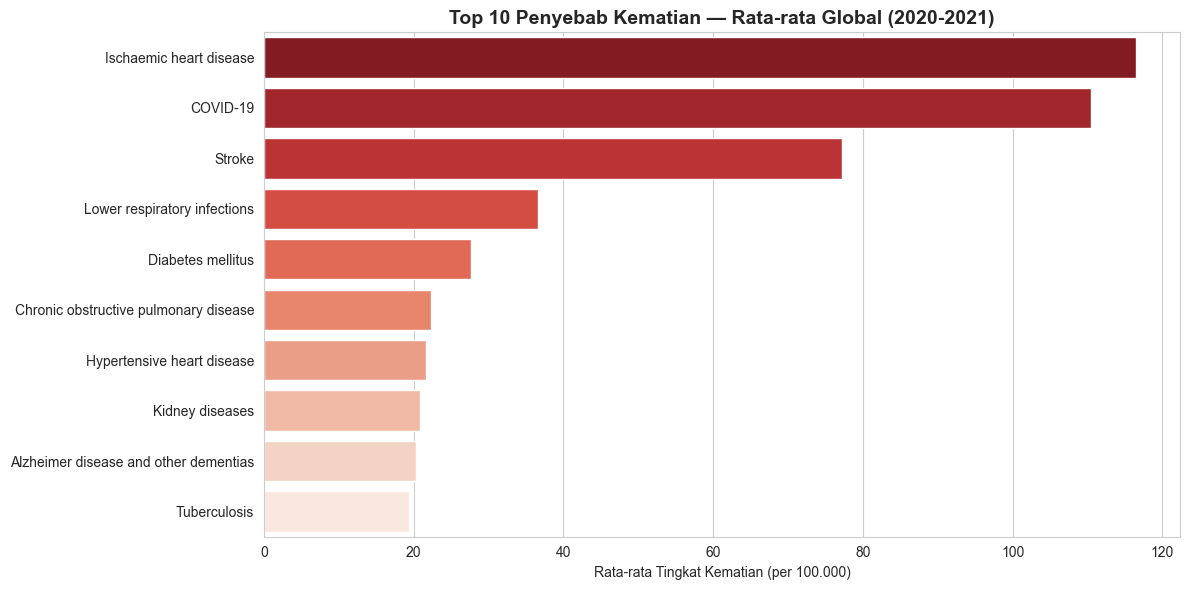

In [30]:
# Plot 1: Top 10 Causes
plt.figure(figsize=(12, 6))
top_causes = q1.reset_index() if ATOTI_AVAIL else q1
sns.barplot(data=top_causes.head(10), y='cause_name', x='death_rate.MEAN',
            palette=sns.color_palette('Reds_r', 10))
plt.title('Top 10 Penyebab Kematian — Rata-rata Global (2020-2021)', fontsize=14, fontweight='bold')
plt.xlabel('Rata-rata Tingkat Kematian (per 100.000)')
plt.ylabel('')
plt.tight_layout()
plt.show()

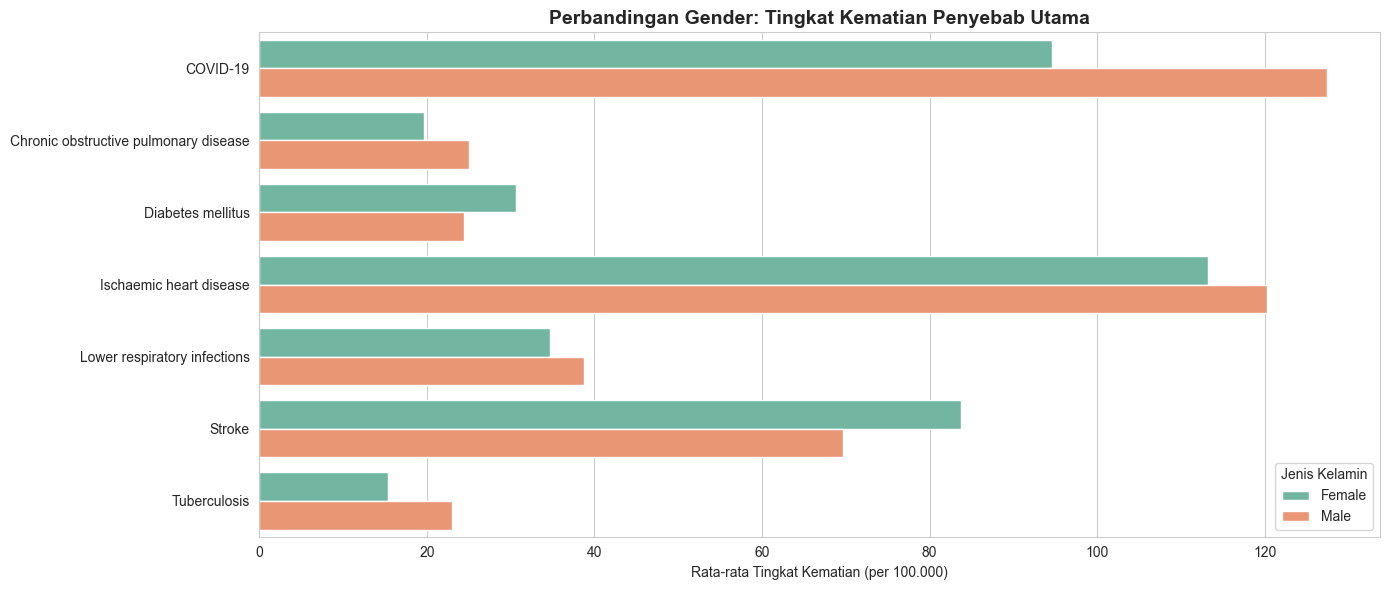

In [31]:
# Plot 2: Gender Comparison
plt.figure(figsize=(14, 6))
q3_plot = q3.reset_index() if ATOTI_AVAIL else q3
sns.barplot(data=q3_plot, x='death_rate.MEAN', y='cause_name',
            hue='sex_name', palette='Set2')
plt.title('Perbandingan Gender: Tingkat Kematian Penyebab Utama', fontsize=14, fontweight='bold')
plt.xlabel('Rata-rata Tingkat Kematian (per 100.000)')
plt.ylabel('')
plt.legend(title='Jenis Kelamin')
plt.tight_layout()
plt.show()

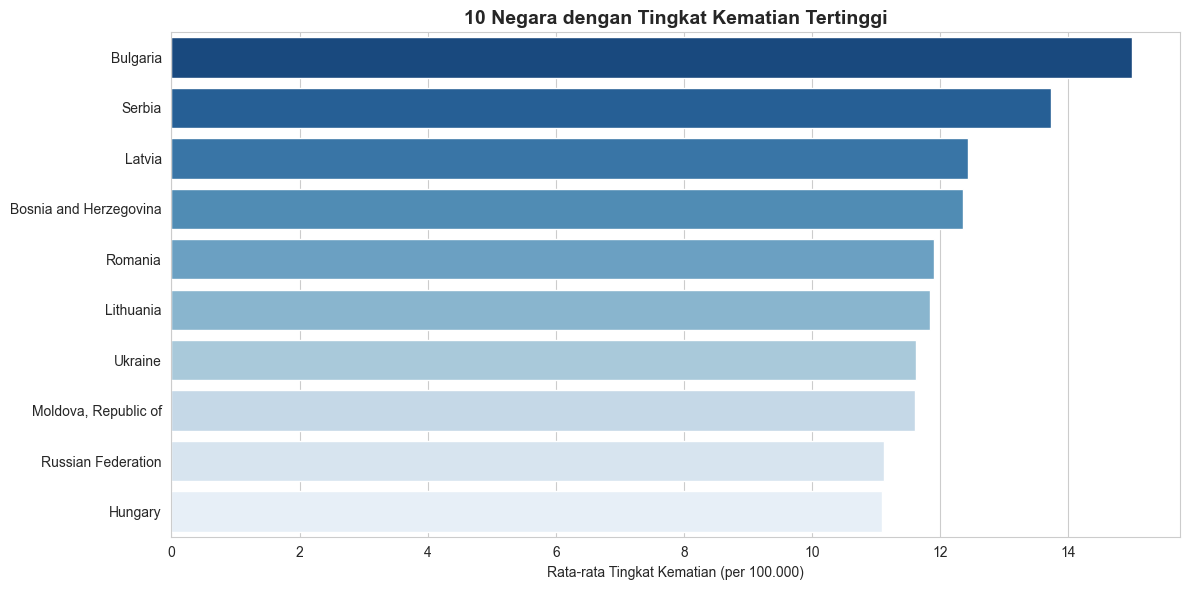

In [32]:
# Plot 3: Top 10 Countries
plt.figure(figsize=(12, 6))
top_ctry = q2.reset_index() if ATOTI_AVAIL else q2
sns.barplot(data=top_ctry.head(10), x='death_rate.MEAN', y='country_name',
            palette='Blues_r')
plt.title('10 Negara dengan Tingkat Kematian Tertinggi', fontsize=14, fontweight='bold')
plt.xlabel('Rata-rata Tingkat Kematian (per 100.000)')
plt.ylabel('')
plt.tight_layout()
plt.show()

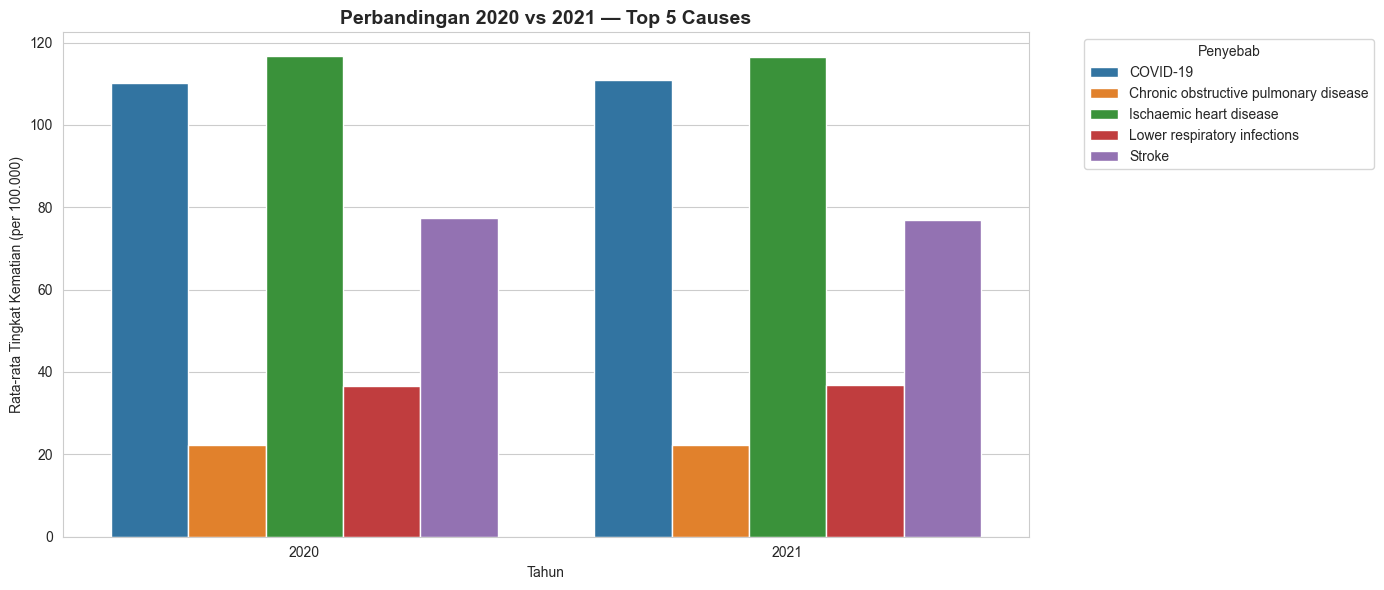

In [33]:
# Plot 4: Year-over-Year Comparison
plt.figure(figsize=(14, 6))
q5_plot = q5.reset_index() if ATOTI_AVAIL else q5
sns.barplot(data=q5_plot, x='year', y='death_rate.MEAN',
            hue='cause_name', palette='tab10')
plt.title('Perbandingan 2020 vs 2021 — Top 5 Causes', fontsize=14, fontweight='bold')
plt.xlabel('Tahun')
plt.ylabel('Rata-rata Tingkat Kematian (per 100.000)')
plt.legend(title='Penyebab', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

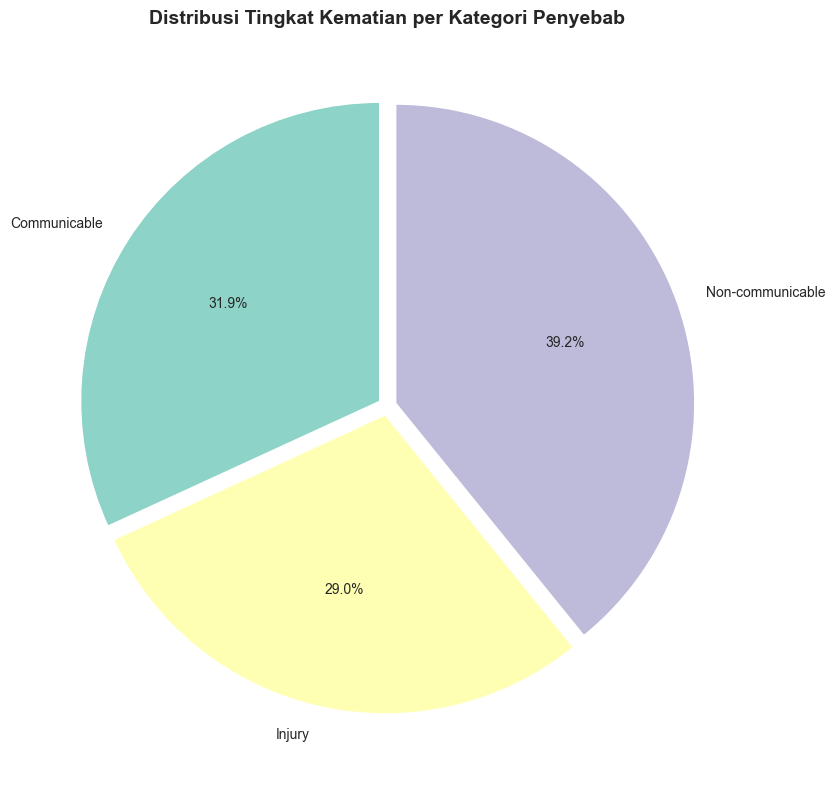

In [34]:
# Plot 5: Distribution by Cause Category
if ATOTI_AVAIL:
    q_cat = cube.query(
        m['death_rate.MEAN'],
        levels=[lev_cause_cat],
        filter=lev_sex == 'Both sexes'
    ).reset_index()
else:
    q_cat = df_both_sex.groupby('cause_category')['death_rate'].mean().reset_index()
    q_cat.columns = ['cause_category', 'death_rate.MEAN']

plt.figure(figsize=(10, 8))
plt.pie(q_cat['death_rate.MEAN'], labels=q_cat['cause_category'],
        autopct='%1.1f%%', colors=sns.color_palette('Set3', 10),
        startangle=90, explode=[0.03]*len(q_cat))
plt.title('Distribusi Tingkat Kematian per Kategori Penyebab', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Export Data (CSV)

In [35]:
dim_country.to_csv('dim_country.csv', index=False)
dim_year.to_csv('dim_year.csv', index=False)
dim_cause.to_csv('dim_cause.csv', index=False)
dim_sex.to_csv('dim_sex.csv', index=False)
fact_mortality.to_csv('fact_mortality.csv', index=False)
fact_life.to_csv('fact_life_expectancy.csv', index=False)
print('Ekspor CSV selesai.')

Ekspor CSV selesai.


---
## Referensi

- **Dataset**: WHO Global Health Estimates (GHE) — Mortality and Life Expectancy
- **Tools**: Python (pandas, numpy, sqlalchemy), PostgreSQL (Supabase), Atoti
- **Metodologi**: Ralph Kimball — The Data Warehouse Toolkit

---
*© 2026 — UAS Data Warehouse | S1 Sains Data Universitas Negeri Surabaya*